# Pearson Korelasyon Testi
Şimdiye kadar birkaç kez kullandığımız `pearsonr()`/`pg.corr()` 
fonksiyonlarının arkasındaki resmi testi şimdi detaylı ele alıyoruz. 
Pearson, **en yaygın kullanılan** korelasyon türüdür — iki **sürekli ve 
doğrusal ilişkili** değişken arasındaki bağı ölçer.

## Hipotezler
- **H0:** İki değişken arasında doğrusal bir ilişki yoktur (ρ=0, popülasyon korelasyonu sıfırdır).
- **H1:** İki değişken arasında doğrusal bir ilişki vardır (ρ≠0).

## Varsayımları (Önceden Kontrol Edilmeli)
1. **Doğrusallık:** İki değişken arasındaki ilişki doğrusal olmalı.
2. **Normallik:** Her iki değişken de (yaklaşık) normal dağılmalı.
3. **Aykırı Değer Yokluğu:** Pearson, aykırı değerlere karşı **çok hassastır** (tek bir uç değer, korelasyonu ciddi şekilde çarpıtabilir bunu birazdan göreceğiz).
4. **Homoscedasticity (Sabit Varyans):** Değişkenlerin yayılımı, ilişkinin her noktasında benzer olmalı.

## Test İstatistiği ve P-Değeri
```python
from scipy.stats import pearsonr

r, p_degeri = pearsonr(x, y)
```
`r`, korelasyon katsayısının kendisi; `p_degeri`, bu r'nin **istatistiksel 
olarak anlamlı** olup olmadığını (yani gerçekten sıfırdan farklı mı, 
yoksa şans eseri mi) test eder.

## Aykırı Değere Duyarlılık — Somut Bir Uyarı
Eğer neredeyse hiç ilişkisi olmayan bir veri setine, **tek bir aşırı 
uç nokta** eklersek, Pearson r'yi ciddi şekilde yükseltebilir/
düşürebiliriz — bu, Pearson'ın en bilinen zayıflıklarından biridir 
(Konu 6'daki "ortalamanın aykırı değerlere duyarlılığı" temasının, 
korelasyondaki karşılığı).

Aykırı değer EKLENMEDEN önce: r=0.0988, p=0.6033
Aykırı değer EKLENDİKTEN sonra: r=0.9111, p=0.0000


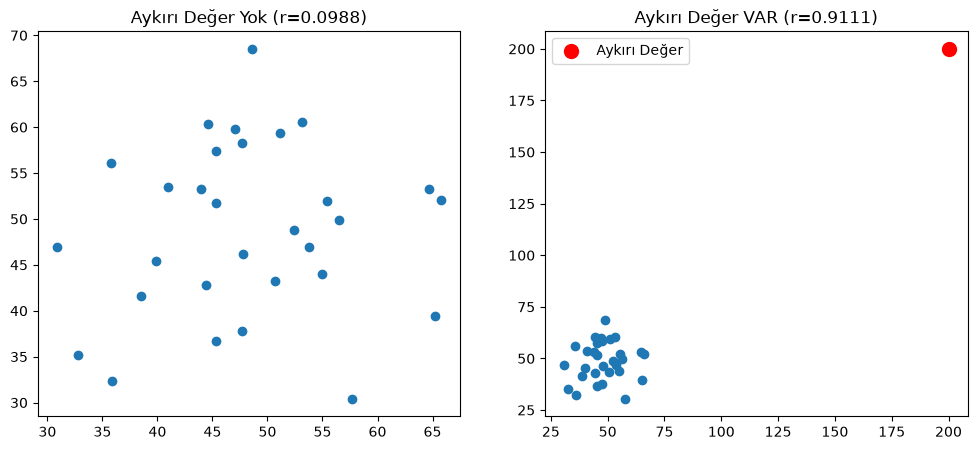

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

# İlişkisiz (rastgele) iki değişken
x = np.random.normal(50, 10, 30)
y = np.random.normal(50, 10, 30)

r_once, p_once = stats.pearsonr(x, y)
print(f"Aykırı değer EKLENMEDEN önce: r={r_once:.4f}, p={p_once:.4f}")

# (200,200) aykırı değer noktası ekleyelim.
x_aykiri = np.append(x, 200)
y_aykiri = np.append(y, 200)

r_sonra, p_sonra = stats.pearsonr(x_aykiri, y_aykiri)
print(f"Aykırı değer EKLENDİKTEN sonra: r={r_sonra:.4f}, p={p_sonra:.4f}")

fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(x, y)
axes[0].set_title(f"Aykırı Değer Yok (r={r_once:.4f})")
axes[1].scatter(x_aykiri, y_aykiri)
axes[1].scatter(200, 200, color='red', s=100, label='Aykırı Değer')
axes[1].set_title(f"Aykırı Değer VAR (r={r_sonra:.4f})")
axes[1].legend()
plt.show()

Yukarıdaki aykırı değersiz ve aykırı değerli scatter plotları incelediğimizde, aykırı değer yokken (sol grafik) r değerinin neredeyse hiç ilişki yok şeklinde çıktığı gözlemlenirken (r=0.0988), tek bir aykırı değer ekleyip (200,200) sağ grafikte yeniden scatter plot çizdiğimizde korelasyon katsayının 0.9111 gibi çok güçlü düzeyde çıktığını gözlemlemekteyiz. Sonuç olarak korelasyon testi yaparken, aykırı değerlerin varlığını kontrol etmemiz daha doğru sonuçlar almamız açısından kritiktir.